In [80]:
import pandas as pd
import matplotlib.pyplot as plt

In [81]:
conversion = pd.read_json('conversion.json')
ads = pd.read_json('ads.json')

In [82]:
conversion['date_group'] = pd.to_datetime(conversion['date_group'])
ads['date_group'] = pd.to_datetime(ads['date_group'])

In [83]:
conversion.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,844,8,0.947867
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355


In [84]:
ads.head()

,date_group,visits,registrations,utm_campaign,cost
0,2023-03-01,941,87,advanced_algorithms_series,212
1,2023-03-02,1226,106,advanced_algorithms_series,252
2,2023-03-03,1564,107,advanced_algorithms_series,202
3,2023-03-04,1754,159,advanced_algorithms_series,223
4,2023-03-05,1838,115,advanced_algorithms_series,265


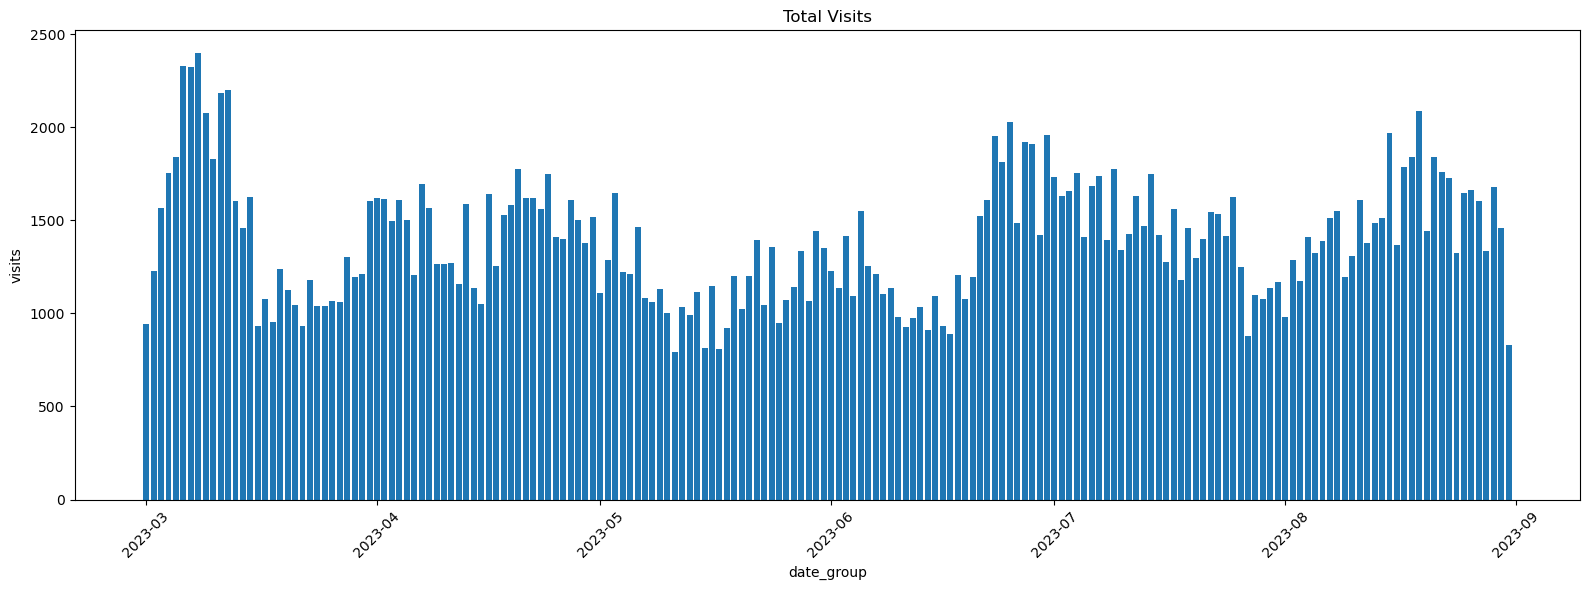

In [85]:
total_visits = conversion.groupby('date_group', as_index=False)['visits'].sum()

plt.figure(figsize=(16, 6))

plt.bar(total_visits['date_group'], total_visits['visits'])

plt.title('Total Visits')
plt.xlabel('date_group')
plt.ylabel('visits')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('./charts/total_visits.png')
plt.show()

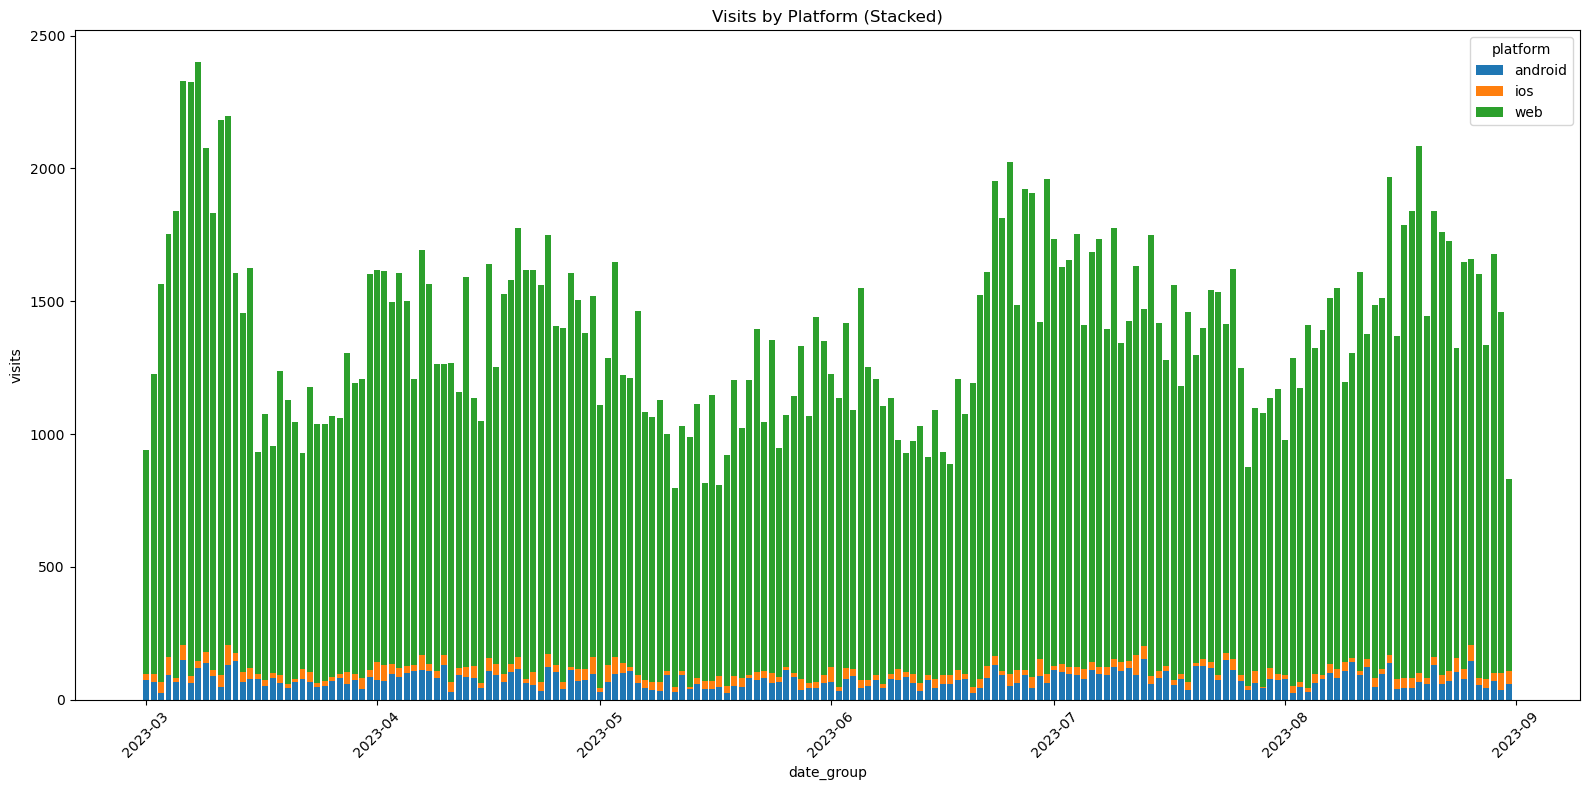

In [86]:
visits_platform = conversion.pivot_table(
    index='date_group',
    columns='platform',
    values='visits',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(16, 8))

plt.bar(visits_platform.index, visits_platform['android'], label='android')
plt.bar(
    visits_platform.index,
    visits_platform['ios'],
    bottom=visits_platform['android'],
    label='ios'
)
plt.bar(
    visits_platform.index,
    visits_platform['web'],
    bottom=visits_platform['android'] + visits_platform['ios'],
    label='web'
)

plt.title('Visits by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('visits')
plt.xticks(rotation=45)
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/visits_by_platform.png')
plt.show()

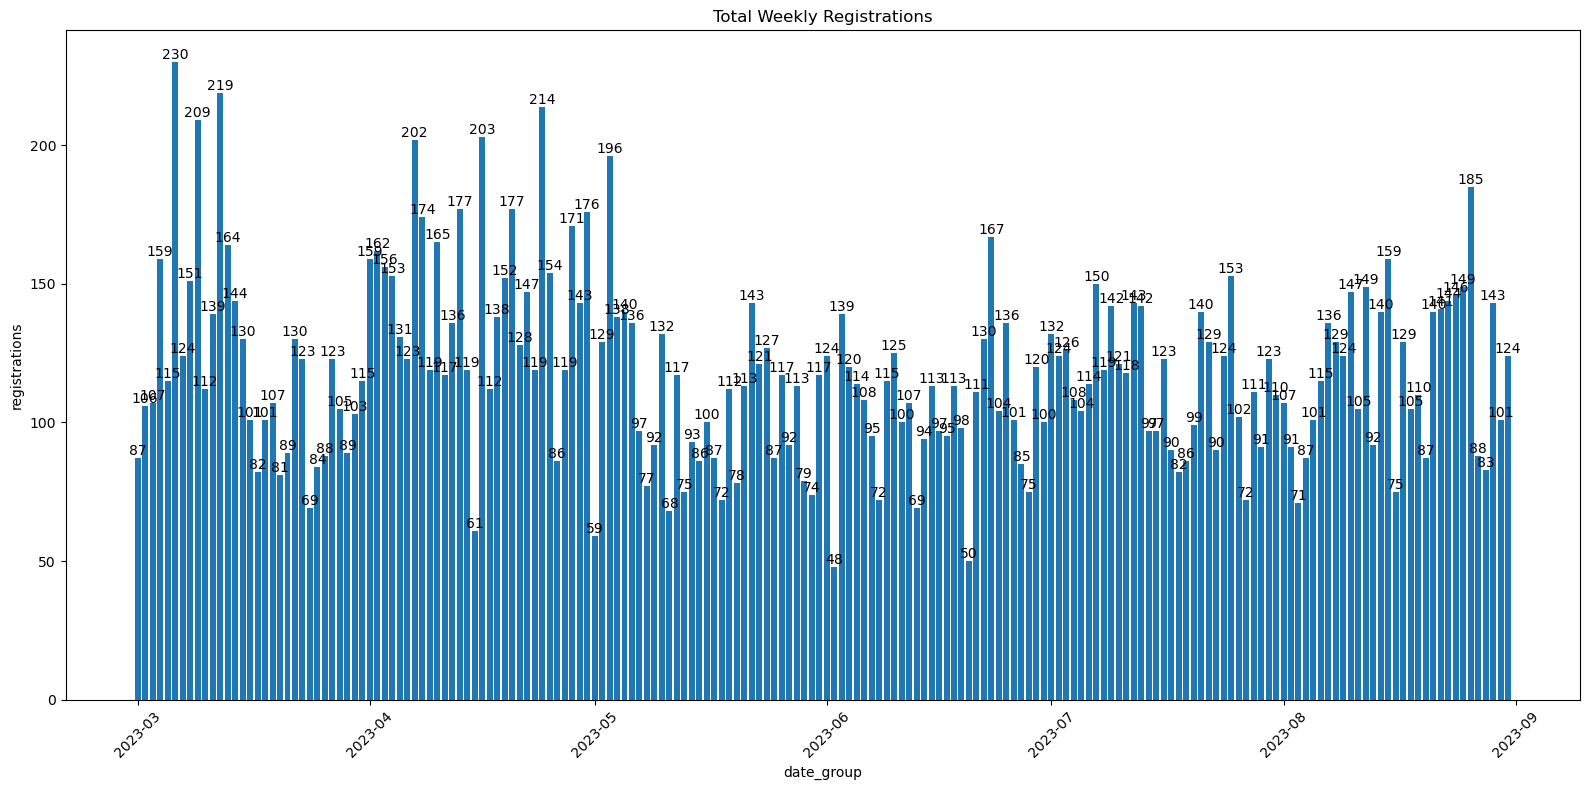

In [87]:
total_registrations = conversion.groupby('date_group', as_index=False)['registrations'].sum()

plt.figure(figsize=(16, 8))

bars = plt.bar(total_registrations['date_group'], total_registrations['registrations'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.title('Total Weekly Registrations')
plt.xlabel('date_group')
plt.ylabel('registrations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./charts/total_registrations.png')
plt.show()

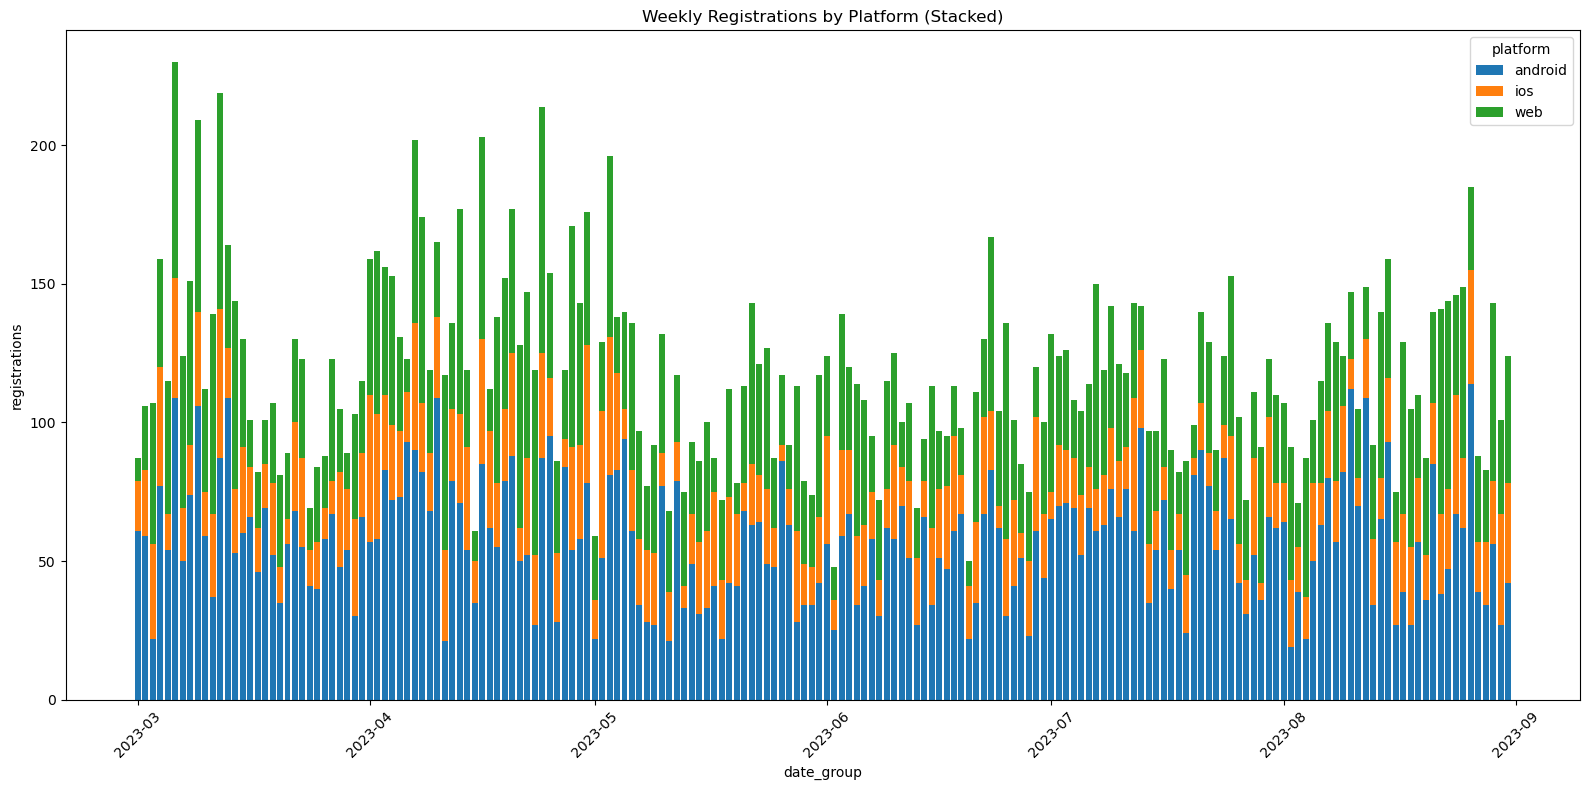

In [88]:
registrations_platform = conversion.pivot_table(
    index='date_group',
    columns='platform',
    values='registrations',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(16, 8))

plt.bar(registrations_platform.index, registrations_platform['android'], label='android')

plt.bar(
    registrations_platform.index,
    registrations_platform['ios'],
    bottom=registrations_platform['android'],
    label='ios'
)

plt.bar(
    registrations_platform.index,
    registrations_platform['web'],
    bottom=registrations_platform['android'] + registrations_platform['ios'],
    label='web'
)

plt.title('Weekly Registrations by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('registrations')

plt.xticks(rotation=45)
plt.legend(title='platform')

plt.tight_layout()
plt.savefig('./charts/registrations_by_platform.png')
plt.show()

In [89]:
conversion_total = (
    conversion
    .groupby('date_group', as_index=False)
    .agg({
        'visits': 'sum',
        'registrations': 'sum'
    })
)

conversion_total['conversion'] = (
    conversion_total['registrations'] / conversion_total['visits']
) * 100



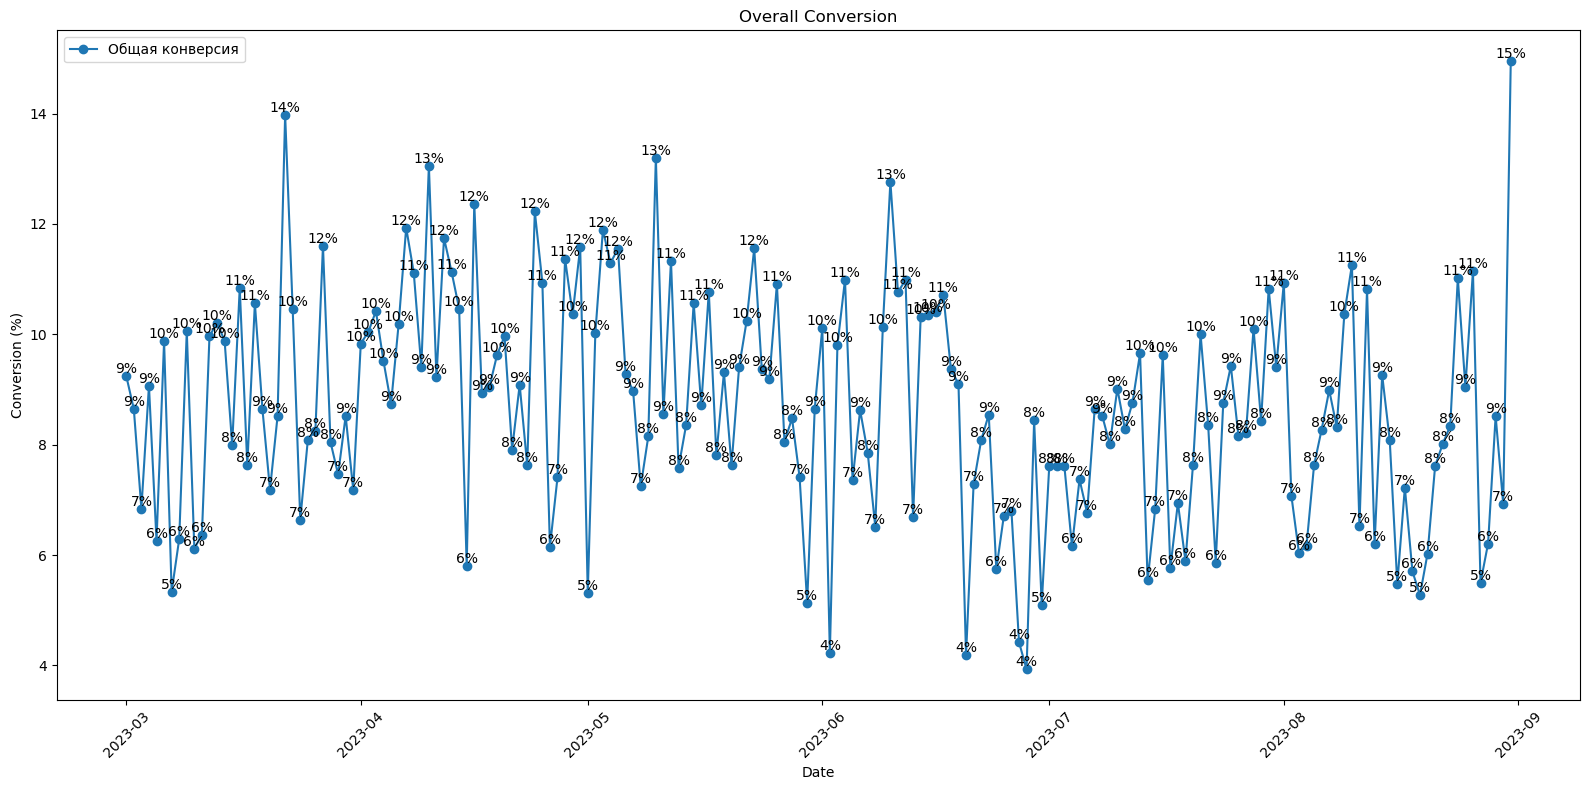

In [90]:
plt.figure(figsize=(16, 8))

plt.plot(
    conversion_total['date_group'],
    conversion_total['conversion'],
    marker='o',
    label='Общая конверсия'
)

for x, y in zip(conversion_total['date_group'], conversion_total['conversion']):
    plt.text(x, y, f'{int(round(y))}%', ha='center', va='bottom')

plt.title('Overall Conversion')
plt.xlabel('Date')
plt.ylabel('Conversion (%)')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')
plt.show()

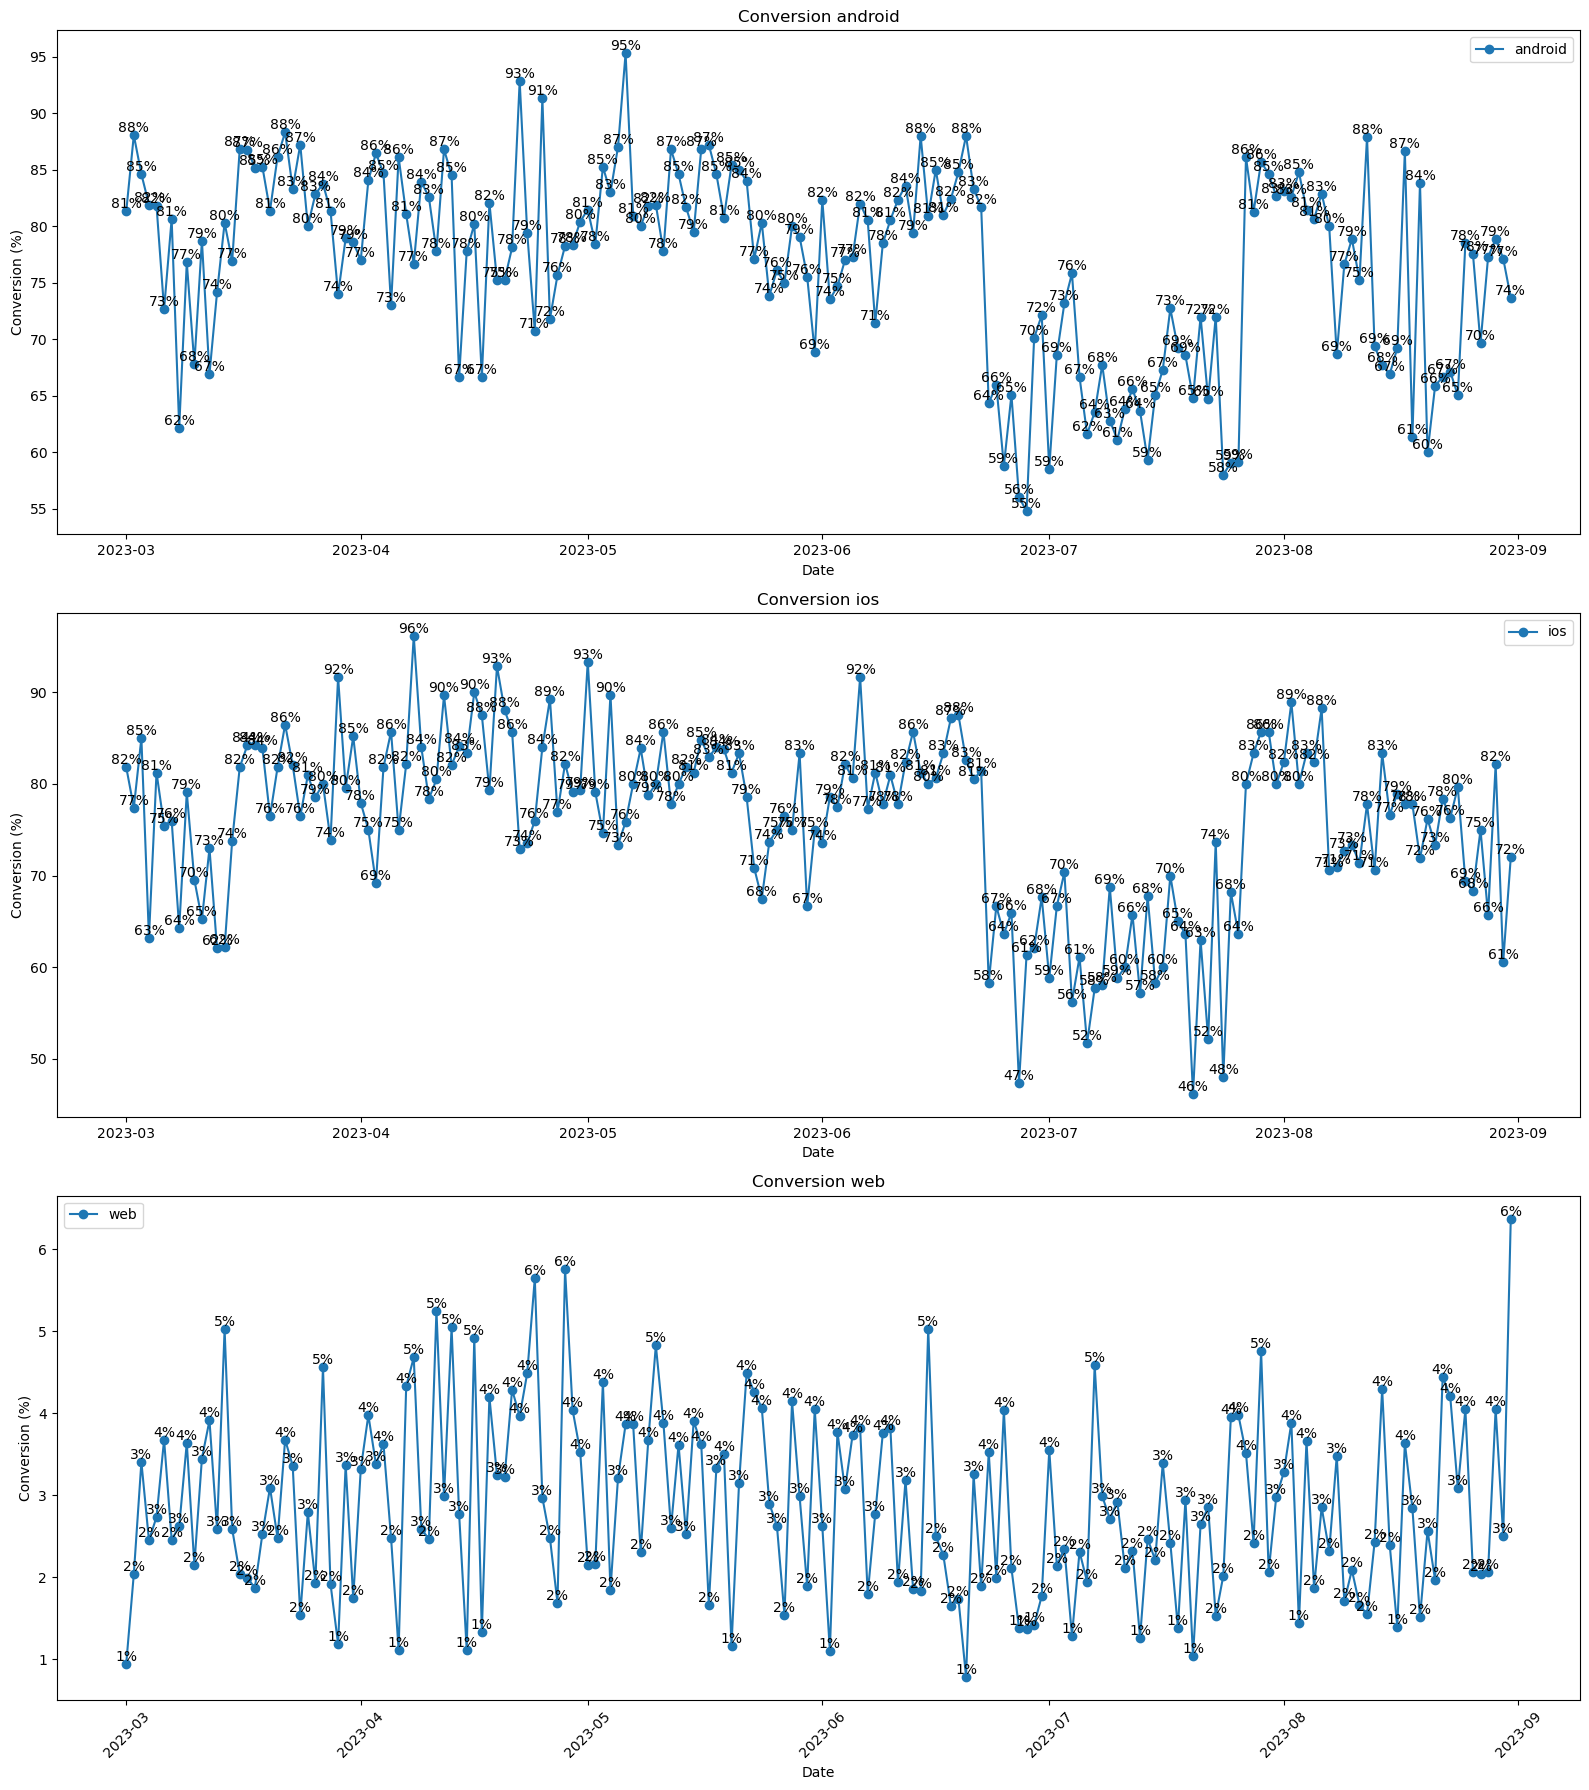

In [91]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

platforms = ['android', 'ios', 'web']

for i, platform in enumerate(platforms):
    data = conversion[conversion['platform'] == platform].sort_values('date_group')

    axes[i].plot(
        data['date_group'],
        data['conversion'],
        marker='o',
        label=platform
    )

 
    for x, y in zip(data['date_group'], data['conversion']):
        axes[i].text(x, y, f'{int(round(y))}%', ha='center', va='bottom')

    axes[i].set_title(f'Conversion {platform}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Conversion (%)')
    axes[i].legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('./charts/conversion_by_platform.png')
plt.show()

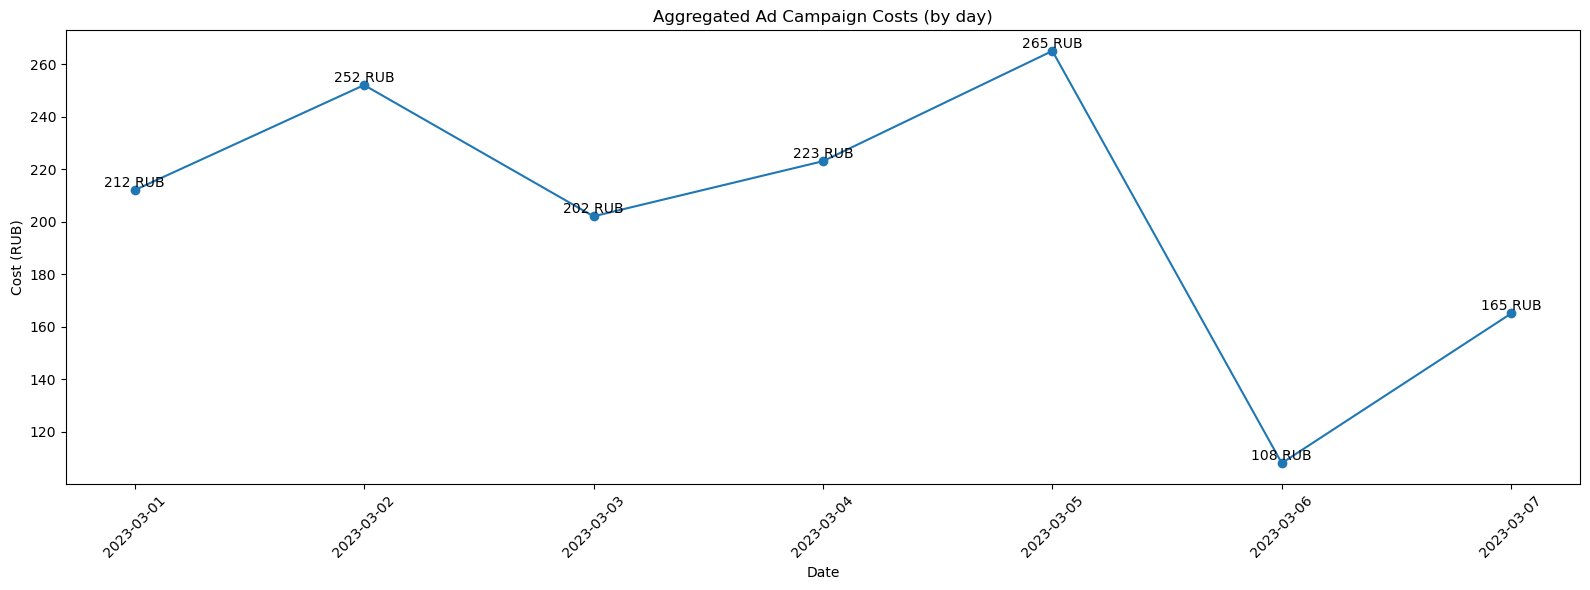

In [92]:
plt.figure(figsize=(16, 6))

plt.plot(
    ads_grouped['date_group'],
    ads_grouped['cost'],
    marker='o'
)


for x, y in zip(ads_grouped['date_group'], ads_grouped['cost']):
    plt.text(
        x,
        y,
        f'{int(y)} RUB',
        ha='center',
        va='bottom'
    )

plt.title('Aggregated Ad Campaign Costs (by day)')
plt.xlabel('Date')
plt.ylabel('Cost (RUB)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('./charts/ad_costs.png')
plt.show()

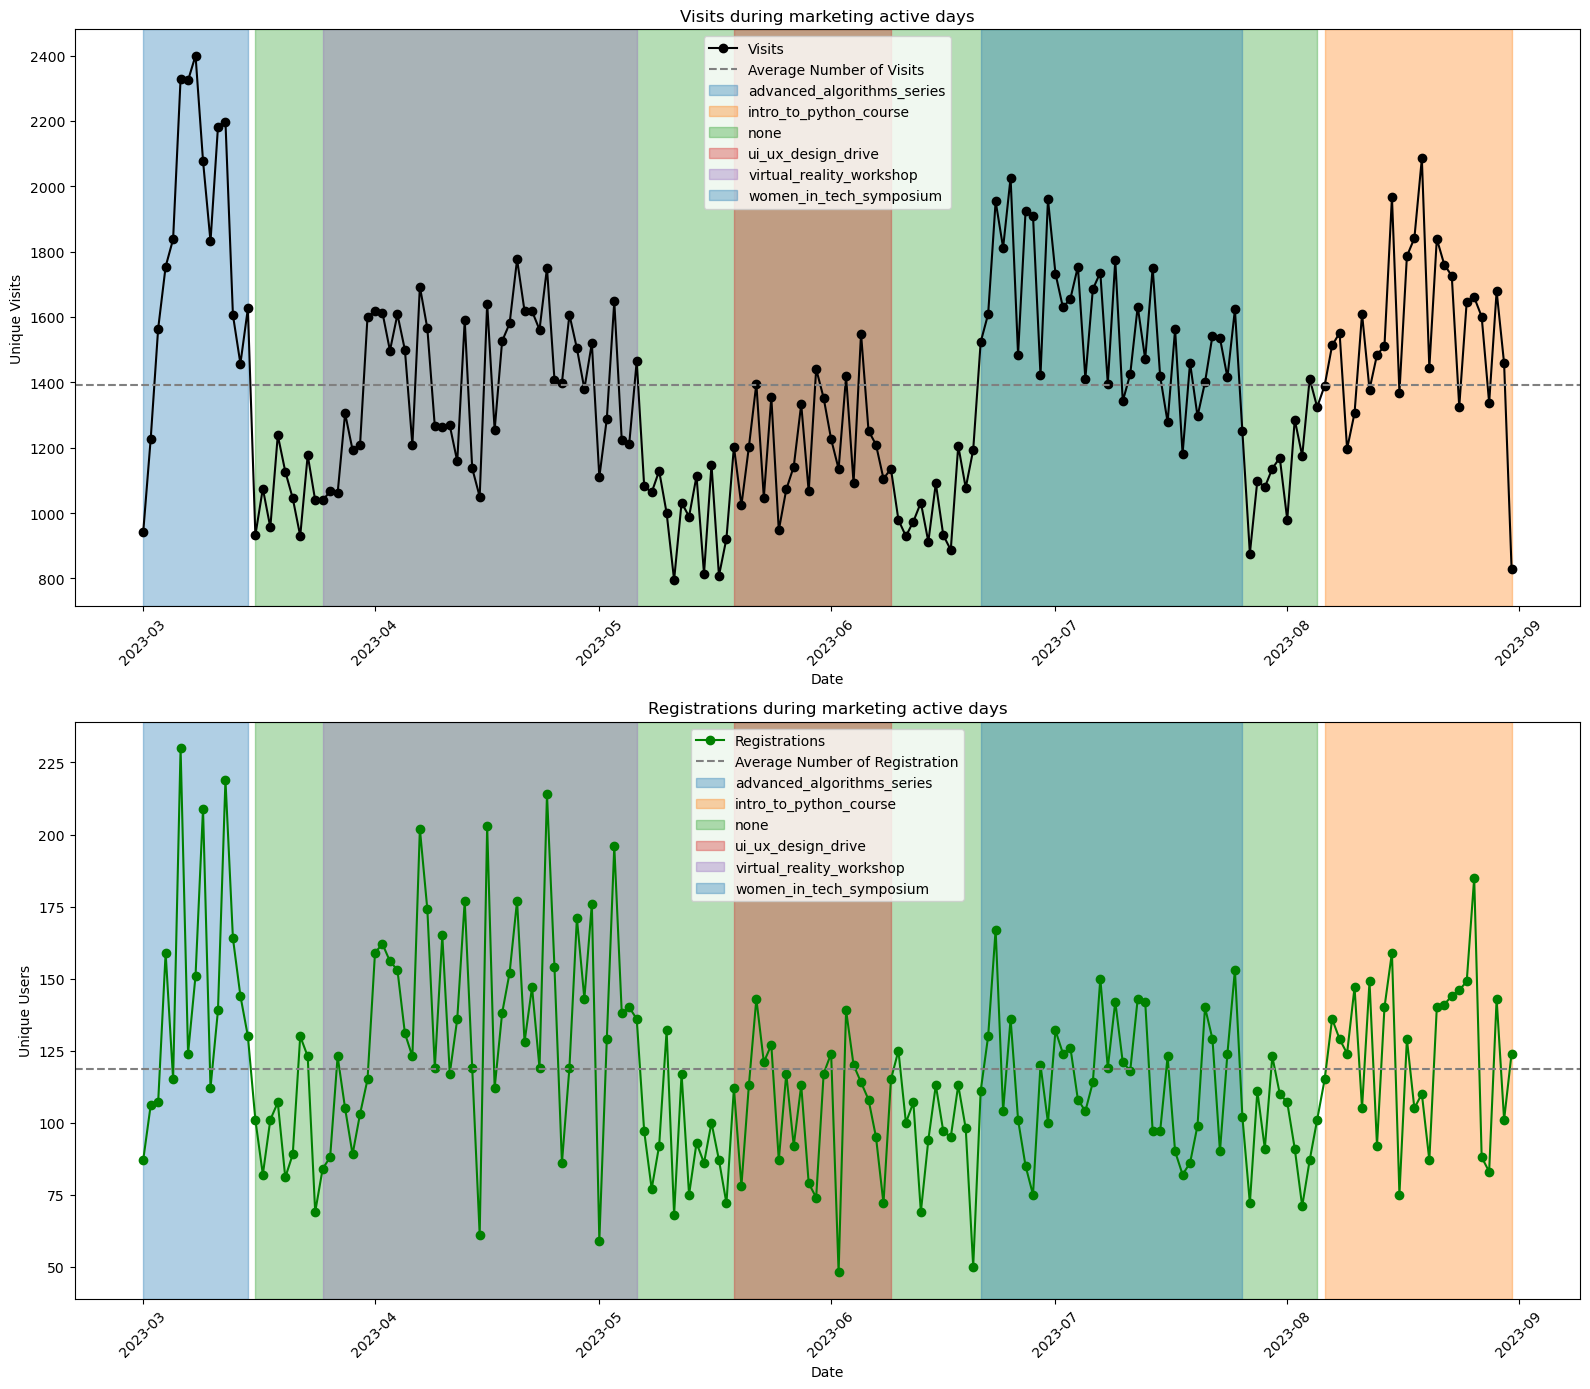

In [93]:
visits_total = conversion.groupby('date_group', as_index=False)['visits'].sum()
registrations_total = conversion.groupby('date_group', as_index=False)['registrations'].sum()

ads_periods = ads.groupby('utm_campaign', as_index=False).agg(
    start_date=('date_group', 'min'),
    end_date=('date_group', 'max')
)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --- Верхний график визиты
axes[0].plot(
    visits_total['date_group'],
    visits_total['visits'],
    color='black',
    marker='o',
    label='Visits'
)

avg_visits = visits_total['visits'].mean()
axes[0].axhline(
    avg_visits,
    linestyle='--',
    color='gray',
    label='Average Number of Visits'
)

for i, row in ads_periods.iterrows():
    axes[0].axvspan(
        row['start_date'],
        row['end_date'],
        alpha=0.35,
        color=colors[i % len(colors)],
        label=row['utm_campaign']
    )

axes[0].set_title('Visits during marketing active days')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Unique Visits')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

#  Нижний график регистрации
axes[1].plot(
    registrations_total['date_group'],
    registrations_total['registrations'],
    color='green',
    marker='o',
    label='Registrations'
)

avg_registrations = registrations_total['registrations'].mean()
axes[1].axhline(
    avg_registrations,
    linestyle='--',
    color='gray',
    label='Average Number of Registration'
)

for i, row in ads_periods.iterrows():
    axes[1].axvspan(
        row['start_date'],
        row['end_date'],
        alpha=0.35,
        color=colors[i % len(colors)],
        label=row['utm_campaign']
    )

axes[1].set_title('Registrations during marketing active days')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Users')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('./charts/marketing_active_days.png')
plt.show()